# Pet Adoption Classification - part 2

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import time

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


# sklearn metrics used only to verify our manual implementations
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve,
)

colors = ['#9b5de5', '#f15bb5', '#fee440', '#00bbf9', '#00f5d4']
cmap_custom = LinearSegmentedColormap.from_list('custom', ['#ffffff', '#9b5de5'])

In [23]:
RANDOM_STATE = 42

## Data Loading
We loaded 8 CSV files prepared in the previous step

In [3]:
df_simple_std = pd.read_csv('data_after_processing/df_simple_std.csv')
df_simple2_std = pd.read_csv('data_after_processing/df_simple2_std.csv')
df_knn_std = pd.read_csv('data_after_processing/df_knn_std.csv')
df_pycaret_std = pd.read_csv('data_after_processing/df_pycaret_std.csv')

df_simple_minmax = pd.read_csv('data_after_processing/df_simple_minmax.csv')
df_simple2_minmax = pd.read_csv('data_after_processing/df_simple2_minmax.csv')
df_knn_minmax = pd.read_csv('data_after_processing/df_knn_minmax.csv')
df_pycaret_minmax = pd.read_csv('data_after_processing/df_pycaret_minmax.csv')

In [4]:
TARGET = 'AdoptionLikelihood'

For convenient iteration we register all 8 dataset variants in a dictionary.

In [9]:
DATASETS = {
    'simple_std':     df_simple_std,
    'simple2_std':    df_simple2_std,
    'knn_std':        df_knn_std,
    'pycaret_std':    df_pycaret_std,
    'simple_minmax':  df_simple_minmax,
    'simple2_minmax': df_simple2_minmax,
    'knn_minmax':     df_knn_minmax,
    'pycaret_minmax': df_pycaret_minmax,
}

for name, df in DATASETS.items():
    print(f'{name:<16}  shape={df.shape}  '
          f'class balance={df[TARGET].value_counts(normalize=True).round(3).to_dict()}')

simple_std        shape=(2007, 25)  class balance={0: 0.672, 1: 0.328}
simple2_std       shape=(2007, 25)  class balance={0: 0.672, 1: 0.328}
knn_std           shape=(2007, 25)  class balance={0.0: 0.672, 1.0: 0.328}
pycaret_std       shape=(2007, 25)  class balance={0: 0.672, 1: 0.328}
simple_minmax     shape=(2007, 25)  class balance={0: 0.672, 1: 0.328}
simple2_minmax    shape=(2007, 25)  class balance={0: 0.672, 1: 0.328}
knn_minmax        shape=(2007, 25)  class balance={0.0: 0.672, 1.0: 0.328}
pycaret_minmax    shape=(2007, 25)  class balance={0: 0.672, 1: 0.328}


## Manual Train / Test Split

Manual stratified split - without using `train_test_split` from sklearn

In [10]:
def manual_train_test_split(df, target_column, test_size=0.2, random_state=42):
    random_generator = np.random.default_rng(random_state)
    
    train_idx = []
    test_idx = []

    for class_label in df[target_column].unique():
        class_idx = df.index[df[target_column] == class_label].tolist()
        
        random_generator.shuffle(class_idx)
        
        num_test_samples = max(1, int(len(class_idx) * test_size))
        
        test_idx.extend(class_idx[:num_test_samples])
        train_idx.extend(class_idx[num_test_samples:])

    train_set = df.loc[train_idx].sample(frac=1, random_state=random_state).reset_index(drop=True)
    test_set  = df.loc[test_idx].sample(frac=1, random_state=random_state).reset_index(drop=True)

    return train_set, test_set

In [11]:
train_ex, test_ex = manual_train_test_split(df_simple_std, TARGET)

print(f'Train size: {len(train_ex)}, Test size: {len(test_ex)}')
print('Train balance:', train_ex[TARGET].value_counts(normalize=True).round(3).to_dict())
print('Test balance: ', test_ex[TARGET].value_counts(normalize=True).round(3).to_dict())
print('Original:    ', df_simple_std[TARGET].value_counts(normalize=True).round(3).to_dict())

Train size: 1607, Test size: 400
Train balance: {0: 0.671, 1: 0.329}
Test balance:  {0: 0.672, 1: 0.328}
Original:     {0: 0.672, 1: 0.328}


## Manual implementation of classification metrics

For binary classification we implement from scratch:
- **Confusion matrix**
- **Accuracy** = $(TP + TN) / (TP + TN + FP + FN)$
- **Precision** = $TP / (TP + FP)$
- **Recall** = $TP / (TP + FN)$
- **F1-score** = $2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$
- **ROC-AUC** - via trapezoidal integration over the ROC curve.

In [46]:
def manual_confusion_matrix(y_true, y_pred, num_classes=2):
    """Build a confusion matrix where rows are true labels and columns are predicted labels."""
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for true_label, pred_label in zip(y_true, y_pred):
        cm[true_label, pred_label] += 1
    return cm

def manual_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(y_true == y_pred))


def manual_precision(y_true, y_pred, positive_class=1):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    tp = int(np.sum((y_pred == positive_class) & (y_true == positive_class)))
    fp = int(np.sum((y_pred == positive_class) & (y_true != positive_class)))
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0


def manual_recall(y_true, y_pred, positive_class=1):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    tp = int(np.sum((y_pred == positive_class) & (y_true == positive_class)))
    fn = int(np.sum((y_pred != positive_class) & (y_true == positive_class)))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0


def manual_f1(y_true, y_pred, positive_class=1):
    p = manual_precision(y_true, y_pred, positive_class)
    r = manual_recall(y_true, y_pred, positive_class)
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0


def manual_roc_auc(y_true, y_score):
    '''Compute ROC-AUC via trapezoidal integration of the ROC curve.'''
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    # Sort samples by descending score
    order = np.argsort(-y_score, kind='mergesort')
    y_true_sorted = y_true[order]

    P = int(np.sum(y_true == 1))
    N = int(np.sum(y_true == 0))
    if P == 0 or N == 0:
        return 0.5

    # TPR = cumulative positives / total positives
    # FPR = cumulative negatives / total negatives
    tpr = np.cumsum(y_true_sorted == 1) / P
    fpr = np.cumsum(y_true_sorted == 0) / N

    # Prepend (0, 0) so curve starts at origin
    tpr = np.concatenate(([0.0], tpr))
    fpr = np.concatenate(([0.0], fpr))

    return float(np.trapezoid(tpr, fpr))

### Verification against sklearn

In [47]:
rng_check = np.random.default_rng(0)
y_true_chk = rng_check.integers(0, 2, size=500)
y_score_chk = 0.3 * y_true_chk + rng_check.random(500)
y_score_chk = (y_score_chk - y_score_chk.min()) / (y_score_chk.max() - y_score_chk.min())
y_pred_chk = (y_score_chk > 0.5).astype(int)

print(f'{'metric':<12} {'manual':>10} {'sklearn':>10}')
print('-' * 34)
print(f'{'accuracy':<12} {manual_accuracy(y_true_chk, y_pred_chk):>10.6f} {accuracy_score(y_true_chk, y_pred_chk):>10.6f}')
print(f'{'precision':<12} {manual_precision(y_true_chk, y_pred_chk):>10.6f} {precision_score(y_true_chk, y_pred_chk):>10.6f}')
print(f'{'recall':<12} {manual_recall(y_true_chk, y_pred_chk):>10.6f} {recall_score(y_true_chk, y_pred_chk):>10.6f}')
print(f'{'f1':<12} {manual_f1(y_true_chk, y_pred_chk):>10.6f} {f1_score(y_true_chk, y_pred_chk):>10.6f}')
print(f'{'roc_auc':<12} {manual_roc_auc(y_true_chk, y_score_chk):>10.6f} {roc_auc_score(y_true_chk, y_score_chk):>10.6f}')

print('\nConfusion matrix (manual):')
print(manual_confusion_matrix(y_true_chk, y_pred_chk))
print('Confusion matrix (sklearn):')
print(confusion_matrix(y_true_chk, y_pred_chk))

metric           manual    sklearn
----------------------------------
accuracy       0.670000   0.670000
precision      0.713178   0.713178
recall         0.669091   0.669091
f1             0.690432   0.690432
roc_auc        0.776178   0.776178

Confusion matrix (manual):
[[151  74]
 [ 91 184]]
Confusion matrix (sklearn):
[[151  74]
 [ 91 184]]


## Manual Stratified Cross-Validation

In [19]:
def manual_stratified_kfold(df, target_column, n_splits=5, random_state=42):
    '''Generator yielding stratified (train_idx, val_idx) splits as positional indices.'''
    rng = np.random.default_rng(random_state)

    folds_per_class = {}
    for class_label in sorted(df[target_column].unique()):
        positions = np.where(df[target_column].to_numpy() == class_label)[0]
        rng.shuffle(positions)
        # Distribute this class's samples evenly into n_splits folds
        folds_per_class[class_label] = np.array_split(positions, n_splits)

    for fold_i in range(n_splits):
        val_idx = np.concatenate([folds_per_class[c][fold_i] for c in folds_per_class])
        train_idx = np.concatenate([
            folds_per_class[c][j]
            for c in folds_per_class
            for j in range(n_splits) if j != fold_i
        ])

        rng.shuffle(train_idx)
        rng.shuffle(val_idx)

        yield train_idx, val_idx

In [21]:
print(f'Original balance: {df_simple_std[TARGET].value_counts(normalize=True).round(3).to_dict()}\n')

for fold_i, (tr_idx, vl_idx) in enumerate(manual_stratified_kfold(df_simple_std, TARGET, n_splits=5)):
    tr_bal = df_simple_std.iloc[tr_idx][TARGET].value_counts(normalize=True).round(3).to_dict()
    vl_bal = df_simple_std.iloc[vl_idx][TARGET].value_counts(normalize=True).round(3).to_dict()
    overlap = len(set(tr_idx) & set(vl_idx))
    print(f'Fold {fold_i + 1}: train={len(tr_idx)} {tr_bal}  val={len(vl_idx)} {vl_bal}  overlap={overlap}')

Original balance: {0: 0.672, 1: 0.328}

Fold 1: train=1605 {0: 0.672, 1: 0.328}  val=402 {0: 0.672, 1: 0.328}  overlap=0
Fold 2: train=1605 {0: 0.672, 1: 0.328}  val=402 {0: 0.672, 1: 0.328}  overlap=0
Fold 3: train=1605 {0: 0.672, 1: 0.328}  val=402 {0: 0.672, 1: 0.328}  overlap=0
Fold 4: train=1606 {0: 0.672, 1: 0.328}  val=401 {0: 0.671, 1: 0.329}  overlap=0
Fold 5: train=1607 {0: 0.671, 1: 0.329}  val=400 {0: 0.672, 1: 0.328}  overlap=0


## Models

We compare 7 classifiers:

**From scikit-learn (4):**
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

**From other libraries (3):**

-
-
-
-

In [24]:
def build_models(random_state=RANDOM_STATE):
    """Return a dict mapping model name to a fresh model instance."""
    return {
        'LogisticRegression': LogisticRegression(max_iter=1000, random_state=random_state),
        'DecisionTree':       DecisionTreeClassifier(random_state=random_state),
        'RandomForest':       RandomForestClassifier(n_estimators=200, random_state=random_state, n_jobs=-1),
        'GradientBoosting':   GradientBoostingClassifier(random_state=random_state),
        # add additional models here
    }

print('Models:')
for name in build_models():
    print(f'  - {name}')

Models:
  - LogisticRegression
  - DecisionTree
  - RandomForest
  - GradientBoosting


## Cross-Validation Evaluation

For every (dataset variant, model) pair we run 5-fold stratified CV and collect:
- accuracy, precision, recall, F1, ROC-AUC (mean ± std across folds)
- mean fit time per fold

In [25]:
def evaluate_cv(model, train_df, feature_cols, target_col, n_splits=5, random_state=RANDOM_STATE):
    """Run stratified k-fold CV and return per-fold metric arrays."""
    fold_metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': [], 'fit_time': []}

    for tr_idx, vl_idx in manual_stratified_kfold(train_df, target_col, n_splits=n_splits, random_state=random_state):
        X_tr = train_df.iloc[tr_idx][feature_cols].to_numpy()
        y_tr = train_df.iloc[tr_idx][target_col].to_numpy()
        X_vl = train_df.iloc[vl_idx][feature_cols].to_numpy()
        y_vl = train_df.iloc[vl_idx][target_col].to_numpy()

        # Clone-via-class-reinit is unnecessary since we instantiate fresh models per dataset.
        t0 = time.time()
        model.fit(X_tr, y_tr)
        fit_time = time.time() - t0

        y_pred = model.predict(X_vl)
        y_proba = model.predict_proba(X_vl)[:, 1]

        fold_metrics['accuracy'].append(manual_accuracy(y_vl, y_pred))
        fold_metrics['precision'].append(manual_precision(y_vl, y_pred))
        fold_metrics['recall'].append(manual_recall(y_vl, y_pred))
        fold_metrics['f1'].append(manual_f1(y_vl, y_pred))
        fold_metrics['roc_auc'].append(manual_roc_auc(y_vl, y_proba))
        fold_metrics['fit_time'].append(fit_time)

    return {k: np.array(v) for k, v in fold_metrics.items()}

### Run all (dataset × model) combinations

This is the main computation. For each of 8 datasets we:
1. Split train/test using `manual_train_test_split`
2. Run 5-fold stratified CV with each of 7 models on the train portion
3. Store the trained model + the held-out test set for later evaluation

Total: 8 × 7 × 5 = 280 model fits.

In [29]:
results_rows = []
trained_artifacts = {}  # (dataset_name, model_name) -> dict with model, train, test

for ds_name, df in DATASETS.items():
    feature_cols = [c for c in df.columns if c != TARGET]
    train_df, test_df = manual_train_test_split(df, TARGET, test_size=0.2, random_state=RANDOM_STATE)

    for model_name, model in build_models().items():
        cv = evaluate_cv(model, train_df, feature_cols, TARGET, n_splits=5)

        results_rows.append({
            'dataset':       ds_name,
            'model':         model_name,
            'accuracy_mean': cv['accuracy'].mean(),
            'accuracy_std':  cv['accuracy'].std(),
            'precision_mean': cv['precision'].mean(),
            'precision_std':  cv['precision'].std(),
            'recall_mean':   cv['recall'].mean(),
            'recall_std':    cv['recall'].std(),
            'f1_mean':       cv['f1'].mean(),
            'f1_std':        cv['f1'].std(),
            'roc_auc_mean':  cv['roc_auc'].mean(),
            'roc_auc_std':   cv['roc_auc'].std(),
            'fit_time_mean': cv['fit_time'].mean(),
        })

        # Refit on the full train set so we can evaluate on the held-out test set later
        X_full = train_df[feature_cols].to_numpy()
        y_full = train_df[TARGET].to_numpy()
        model.fit(X_full, y_full)

        trained_artifacts[(ds_name, model_name)] = {
            'model':        model,
            'train_df':     train_df,
            'test_df':      test_df,
            'feature_cols': feature_cols,
        }

    print(f'Done: {ds_name}')

results = pd.DataFrame(results_rows)
print(f'\nTotal rows: {len(results)}')

Done: simple_std
Done: simple2_std
Done: knn_std
Done: pycaret_std
Done: simple_minmax
Done: simple2_minmax
Done: knn_minmax
Done: pycaret_minmax

Total rows: 32


In [30]:
results

,dataset,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,fit_time_mean
0,simple_std,LogisticRegression,0.747939,0.019401,0.650319,0.049458,0.513226,0.033031,0.572298,0.027363,0.809819,0.023977,0.003087
1,simple_std,DecisionTree,0.838180,0.016499,0.750655,0.039533,0.765013,0.043230,0.756361,0.024130,0.814752,0.026292,0.003041
2,simple_std,RandomForest,0.899769,0.018468,0.891372,0.032169,0.791536,0.033101,0.838303,0.030235,0.918832,0.021011,0.101217
3,simple_std,GradientBoosting,0.916574,0.017752,0.887008,0.035990,0.855957,0.022624,0.871001,0.026597,0.918241,0.024196,0.092832
4,simple2_std,LogisticRegression,0.747314,0.020453,0.649315,0.050839,0.511321,0.035818,0.570722,0.030466,0.809739,0.024156,0.002512
5,simple2_std,DecisionTree,0.841312,0.012812,0.754194,0.037191,0.772633,0.041993,0.761743,0.018295,0.821580,0.014514,0.003000
6,simple2_std,RandomForest,0.900396,0.016626,0.891918,0.031648,0.793441,0.030410,0.839524,0.026905,0.918336,0.020174,0.111671
7,simple2_std,GradientBoosting,0.917197,0.017552,0.888838,0.036213,0.855957,0.022624,0.871850,0.026206,0.918075,0.023069,0.092765
8,knn_std,LogisticRegression,0.747945,0.018393,0.648759,0.044844,0.515130,0.032803,0.573135,0.027530,0.809142,0.023936,0.002045
9,knn_std,DecisionTree,0.860594,0.013691,0.781837,0.045786,0.804888,0.027341,0.791749,0.015174,0.842829,0.014656,0.002923


## Results

### Top-10 (dataset × model) combinations by F1-score

In [32]:
display_cols = ['dataset', 'model',
                'accuracy_mean', 'precision_mean', 'recall_mean',
                'f1_mean', 'roc_auc_mean', 'fit_time_mean']

top10 = results.sort_values('f1_mean', ascending=False).head(10)[display_cols]
top10.style.format({c: '{:.4f}' for c in display_cols if c not in ['dataset', 'model']}).background_gradient(
    subset=['accuracy_mean', 'precision_mean', 'recall_mean', 'f1_mean', 'roc_auc_mean'],
    cmap='Purples'
)

,dataset,model,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean,fit_time_mean
11,knn_std,GradientBoosting,0.9228,0.9115,0.8484,0.8786,0.9194,0.0949
27,knn_minmax,GradientBoosting,0.9228,0.9115,0.8484,0.8786,0.9194,0.0958
31,pycaret_minmax,GradientBoosting,0.9209,0.9089,0.8446,0.8754,0.9249,0.0952
15,pycaret_std,GradientBoosting,0.9209,0.9089,0.8446,0.8754,0.9246,0.0964
23,simple2_minmax,GradientBoosting,0.9172,0.8888,0.8560,0.8718,0.9182,0.0972
7,simple2_std,GradientBoosting,0.9172,0.8888,0.8560,0.8718,0.9181,0.0928
3,simple_std,GradientBoosting,0.9166,0.8870,0.8560,0.8710,0.9182,0.0928
19,simple_minmax,GradientBoosting,0.9166,0.8870,0.8560,0.8710,0.9182,0.0975
14,pycaret_std,RandomForest,0.9091,0.9047,0.8086,0.8539,0.9213,0.1144
30,pycaret_minmax,RandomForest,0.9079,0.9025,0.8067,0.8518,0.9209,0.1102


### Mean F1-score per model (averaged over all dataset variants)

In [33]:
per_model = (
    results.groupby('model')[['accuracy_mean', 'precision_mean', 'recall_mean', 'f1_mean', 'roc_auc_mean']]
           .mean()
           .sort_values('f1_mean', ascending=False)
)
per_model.style.format('{:.4f}').background_gradient(cmap='Purples')

,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean
model,,,,,
GradientBoosting,0.9194,0.8991,0.8512,0.8742,0.9201
RandomForest,0.9034,0.8971,0.7977,0.8443,0.9196
DecisionTree,0.8492,0.7645,0.7869,0.7743,0.8311
LogisticRegression,0.7479,0.6504,0.5116,0.5714,0.8098


### Heatmaps: each metric across (dataset × model)

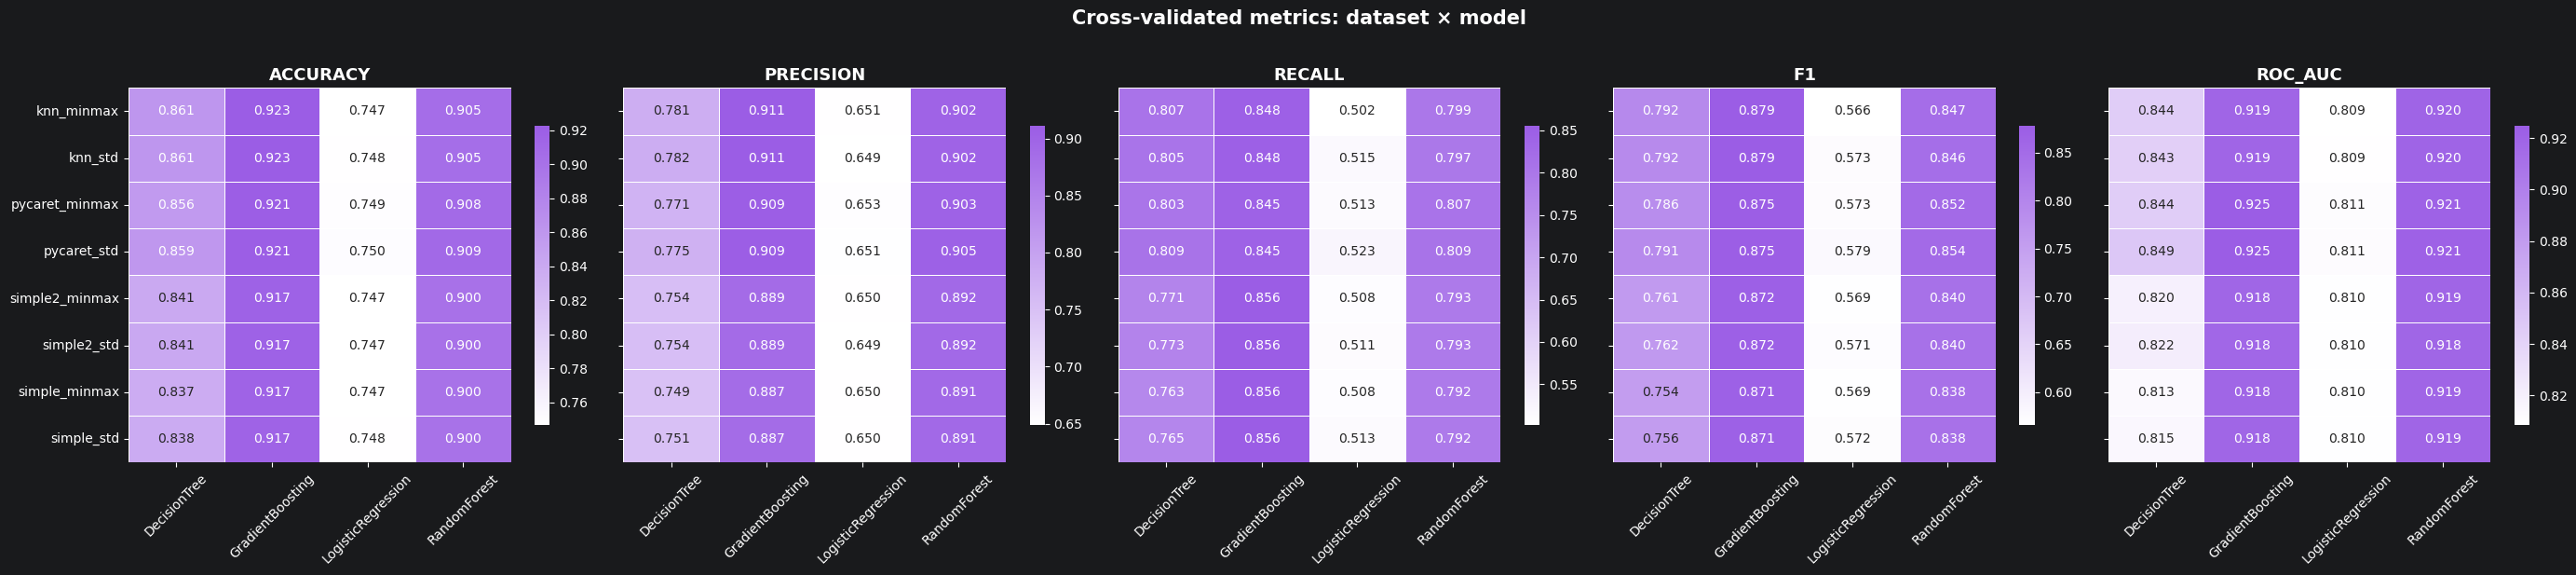

In [36]:
metrics_to_plot = ['accuracy_mean', 'precision_mean', 'recall_mean', 'f1_mean', 'roc_auc_mean']

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(28, 6), sharey=True)

for ax, metric in zip(axes, metrics_to_plot):
    pivot = results.pivot(index='dataset', columns='model', values=metric)
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap=cmap_custom,
                cbar_kws={'shrink': 0.8}, ax=ax, linewidths=0.5, linecolor='white')
    ax.set_title(metric.replace('_mean', '').upper(), fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Cross-validated metrics: dataset × model', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Fit time per model

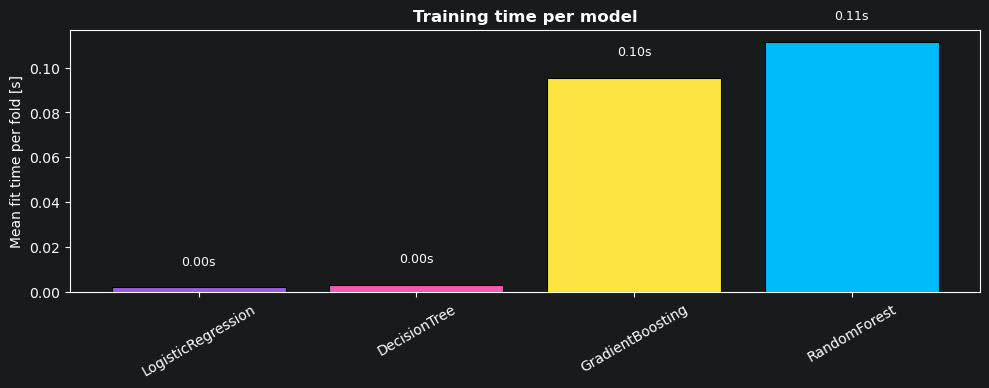

In [38]:
time_summary = results.groupby('model')['fit_time_mean'].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(time_summary.index, time_summary.values,
              color=colors * 2, edgecolor='black', linewidth=0.8)
ax.set_ylabel('Mean fit time per fold [s]')
ax.set_title('Training time per model', fontweight='bold')
ax.tick_params(axis='x', rotation=30)

for bar, val in zip(bars, time_summary.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
            f'{val:.2f}s', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Final Evaluation on the Held-Out Test Set

In [39]:
best_row = results.sort_values('f1_mean', ascending=False).iloc[0]
best_ds, best_model_name = best_row['dataset'], best_row['model']
print(f'Best combination by CV F1-score:')
print(f'  dataset = {best_ds}')
print(f'  model   = {best_model_name}')
print(f'  CV F1   = {best_row["f1_mean"]:.4f} ± {best_row["f1_std"]:.4f}')
print(f'  CV AUC  = {best_row["roc_auc_mean"]:.4f}')

Best combination by CV F1-score:
  dataset = knn_std
  model   = GradientBoosting
  CV F1   = 0.8786 ± 0.0236
  CV AUC  = 0.9194


In [40]:
artifact = trained_artifacts[(best_ds, best_model_name)]
best_model = artifact['model']
test_df = artifact['test_df']
feature_cols = artifact['feature_cols']

X_test = test_df[feature_cols].to_numpy()
y_test = test_df[TARGET].to_numpy()

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print('Test-set metrics for the best model:')
print(f'  accuracy : {manual_accuracy(y_test, y_pred):.4f}')
print(f'  precision: {manual_precision(y_test, y_pred):.4f}')
print(f'  recall   : {manual_recall(y_test, y_pred):.4f}')
print(f'  F1       : {manual_f1(y_test, y_pred):.4f}')
print(f'  ROC-AUC  : {manual_roc_auc(y_test, y_proba):.4f}')

Test-set metrics for the best model:
  accuracy : 0.9200
  precision: 0.9304
  recall   : 0.8168
  F1       : 0.8699
  ROC-AUC  : 0.9305


### Confusion matrices for all 7 models on the best dataset variant

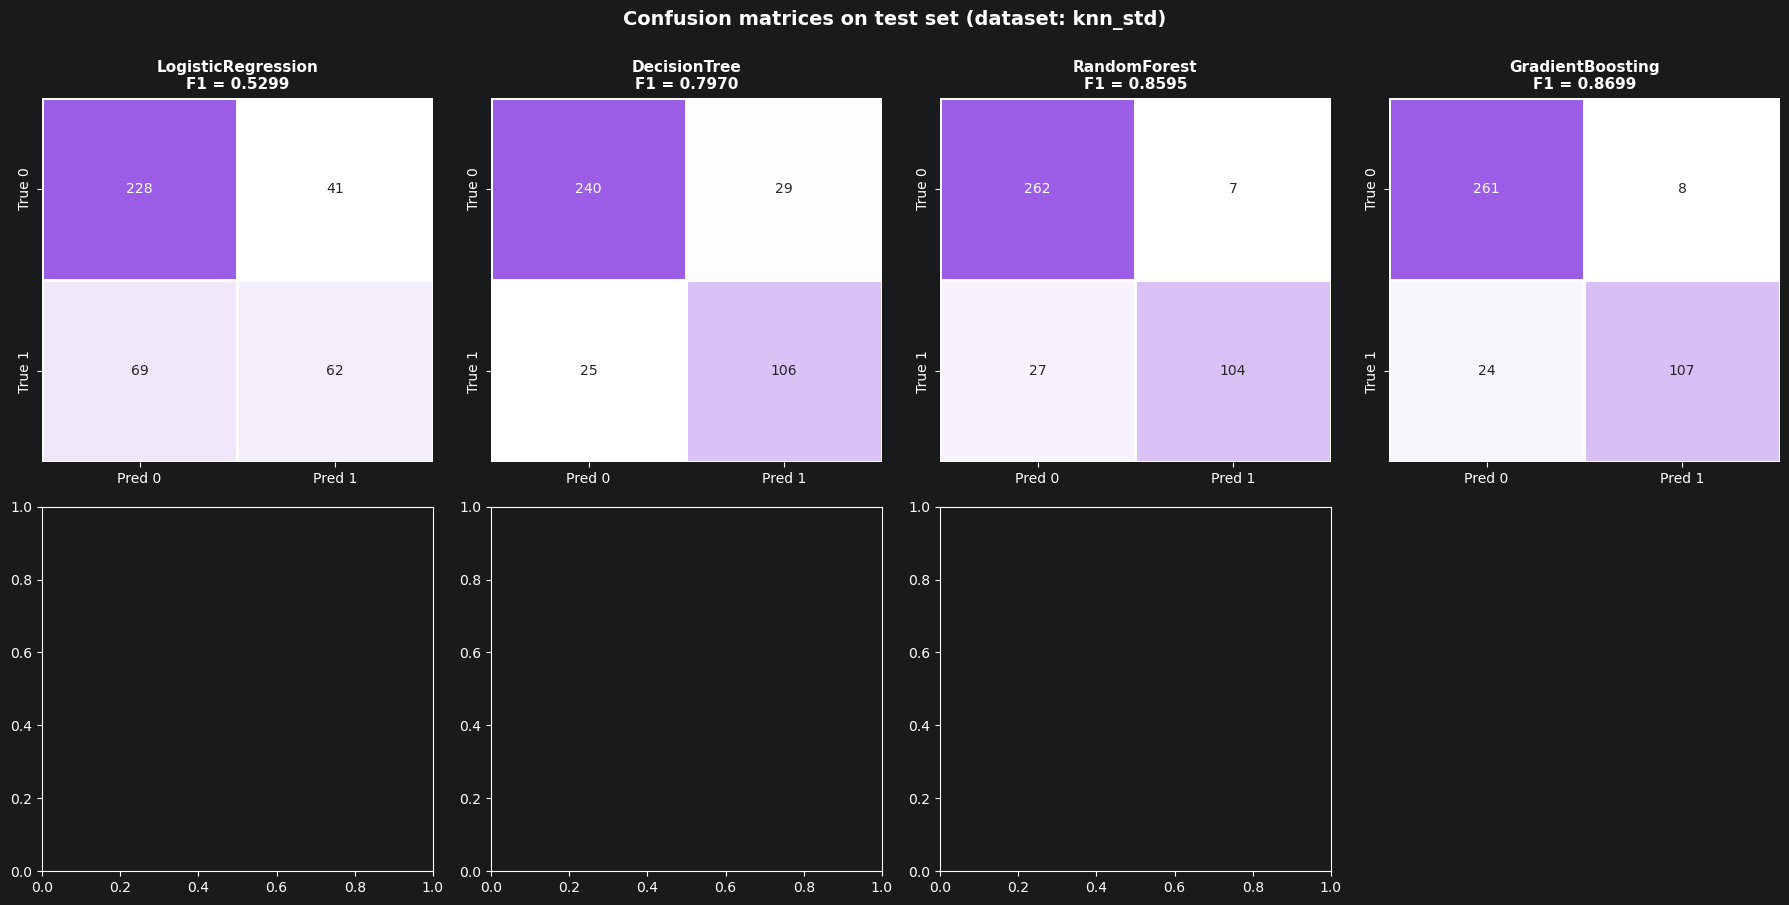

In [48]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for ax, model_name in zip(axes, build_models().keys()):
    art = trained_artifacts[(best_ds, model_name)]
    X_t = art['test_df'][art['feature_cols']].to_numpy()
    y_t = art['test_df'][TARGET].to_numpy()
    y_p = art['model'].predict(X_t)

    cm = manual_confusion_matrix(y_t, y_p, num_classes=2)
    f1 = manual_f1(y_t, y_p)

    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap_custom,
                cbar=False, ax=ax, linewidths=1, linecolor='white',
                xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
    ax.set_title(f'{model_name}\nF1 = {f1:.4f}', fontsize=11, fontweight='bold')

# Hide the last unused subplot
axes[-1].axis('off')

plt.suptitle(f'Confusion matrices on test set (dataset: {best_ds})',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

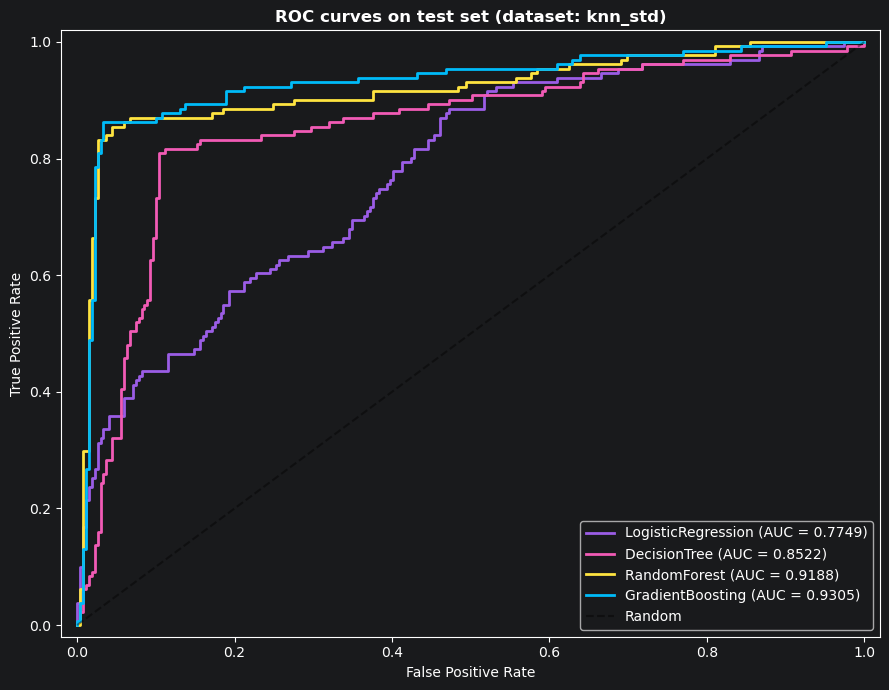

In [45]:
fig, ax = plt.subplots(figsize=(9, 7))

for color, model_name in zip(colors * 2, build_models().keys()):
    art = trained_artifacts[(best_ds, model_name)]
    X_t = art['test_df'][art['feature_cols']].to_numpy()
    y_t = art['test_df'][TARGET].to_numpy()
    y_pr = art['model'].predict_proba(X_t)[:, 1]

    # Build ROC curve manually using the same logic as manual_roc_auc
    order = np.argsort(-y_pr, kind='mergesort')
    y_t_sorted = y_t[order]
    P, N = (y_t == 1).sum(), (y_t == 0).sum()
    tpr = np.concatenate(([0.0], np.cumsum(y_t_sorted == 1) / P))
    fpr = np.concatenate(([0.0], np.cumsum(y_t_sorted == 0) / N))

    auc_val = manual_roc_auc(y_t, y_pr)
    ax.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_val:.4f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC curves on test set (dataset: {best_ds})', fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.show()